<a href="https://colab.research.google.com/github/harshadbabar26-dev/HB1/blob/main/transformation_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving pexels-pixabay-268533.jpg to pexels-pixabay-268533 (1).jpg


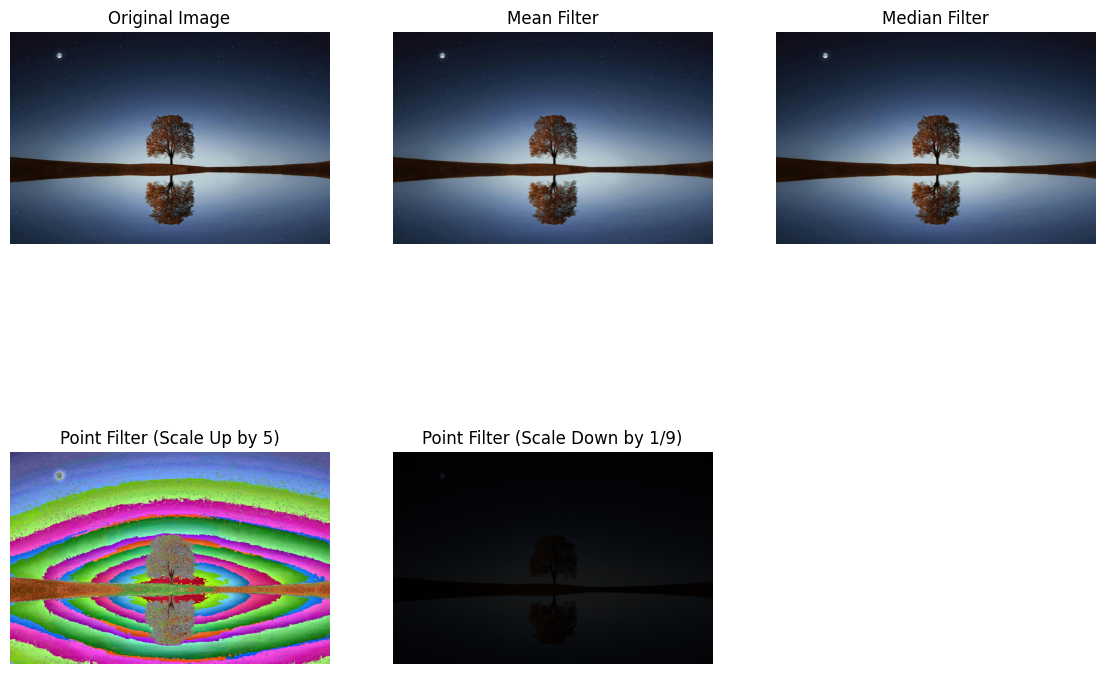

In [3]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image from user
uploaded = files.upload()

# Get uploaded file name
image_name = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_name)

# Convert BGR to RGB for correct display
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -----------------
# Mean Filter
# -----------------
mean_img = cv2.blur(img, (5,5))

# -----------------
# Median Filter
# -----------------
median_img = cv2.medianBlur(img, 5)

# -----------------
# Point Filter - Scale Up by 5
# -----------------
scale_up = np.clip(img * 5, 0, 255).astype(np.uint8)

# -----------------
# Point Filter - Scale Down by 1/9
# -----------------
scale_down = np.clip(img * (1/9), 0, 255).astype(np.uint8)

# -----------------
# Display Results
# -----------------
plt.figure(figsize=(14,10))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(mean_img)
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(median_img)
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(scale_up)
plt.title("Point Filter (Scale Up by 5)")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(scale_down)
plt.title("Point Filter (Scale Down by 1/9)")
plt.axis("off")

plt.show()

Saving 07-FINAL-COMPOSITION-min__ResizedImageWzYwMCwzMTVd.jpg to 07-FINAL-COMPOSITION-min__ResizedImageWzYwMCwzMTVd (1).jpg
Choose Operation
1 Scaling
2 Rotation
3 Translation
4 Affine Transformation
5 Point Filter
6 Mean Filter
7 Median Filter
8 Sobel Filter
9 Gaussian Filter
Enter your choice: 4


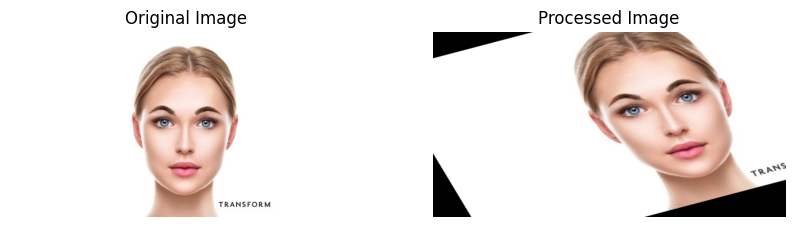

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

class ImageProcessor:

    def __init__(self, image):
        self.img = image

    # Geometric Transformations

    def scaling(self):
        sx = float(input("Enter scale X: "))
        sy = float(input("Enter scale Y: "))
        h, w = self.img.shape[:2]
        return cv2.resize(self.img, (int(w*sx), int(h*sy)))

    def rotation(self):
        angle = float(input("Enter rotation angle: "))
        h, w = self.img.shape[:2]
        center = (w//2, h//2)
        matrix = cv2.getRotationMatrix2D(center, angle, 1)
        return cv2.warpAffine(self.img, matrix, (w, h))

    def translation(self):
        tx = int(input("Enter translation X: "))
        ty = int(input("Enter translation Y: "))
        matrix = np.float32([[1,0,tx],[0,1,ty]])
        h, w = self.img.shape[:2]
        return cv2.warpAffine(self.img, matrix, (w, h))

    def affine(self):
        rows, cols = self.img.shape[:2]
        pts1 = np.float32([[50,50],[200,50],[50,200]])
        pts2 = np.float32([[10,100],[200,50],[100,250]])
        matrix = cv2.getAffineTransform(pts1, pts2)
        return cv2.warpAffine(self.img, matrix, (cols, rows))

    # Filters

    def point_filter(self):
        scale = float(input("Enter scaling value (example 5 or 0.2): "))
        return np.clip(self.img * scale, 0, 255).astype(np.uint8)

    def mean_filter(self):
        return cv2.blur(self.img,(5,5))

    def median_filter(self):
        return cv2.medianBlur(self.img,5)

    def sobel_filter(self):
        gray = cv2.cvtColor(self.img, cv2.COLOR_RGB2GRAY)
        return cv2.Sobel(gray, cv2.CV_64F,1,1,ksize=5)

    def gaussian_filter(self):
        return cv2.GaussianBlur(self.img,(5,5),0)


# -------------------------
# Upload Image
# -------------------------

uploaded = files.upload()
image_name = list(uploaded.keys())[0]

img = cv2.imread(image_name)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Create Object
processor = ImageProcessor(img)

# -------------------------
# Menu
# -------------------------

print("Choose Operation")
print("1 Scaling")
print("2 Rotation")
print("3 Translation")
print("4 Affine Transformation")
print("5 Point Filter")
print("6 Mean Filter")
print("7 Median Filter")
print("8 Sobel Filter")
print("9 Gaussian Filter")

choice = int(input("Enter your choice: "))

# -------------------------
# Object Calling Methods
# -------------------------

if choice == 1:
    result = processor.scaling()

elif choice == 2:
    result = processor.rotation()

elif choice == 3:
    result = processor.translation()

elif choice == 4:
    result = processor.affine()

elif choice == 5:
    result = processor.point_filter()

elif choice == 6:
    result = processor.mean_filter()

elif choice == 7:
    result = processor.median_filter()

elif choice == 8:
    result = processor.sobel_filter()

elif choice == 9:
    result = processor.gaussian_filter()

else:
    print("Invalid choice")
    result = img


# -------------------------
# Display Images
# -------------------------

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result, cmap='gray')
plt.title("Processed Image")
plt.axis("off")

plt.show()